In [1]:
import os
import win32com.client as win32
from y_n import y_n_distribution
from upsilon_n import upsilon_n
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import pandas as pd
from sklearn.model_selection import ParameterSampler, ParameterGrid
import numpy as np

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
kinetic_data = pd.read_pickle('kinetic_data.pkl')

In [4]:
(kinetic_data.P_abs_Pa / 1e5).min()

np.float64(16.611018389999998)

In [5]:
(kinetic_data.P_abs_Pa / 1e5).max()

np.float64(26.125783050000003)

In [6]:
hysys = win32.Dispatch("HYSYS.Application")

In [7]:
os.chdir("Z:\\uem\\Doutorado\\Ensaios\\SAF\\SAF_8_08_08_2025\\SAF_kinetics_paper_code")
path = "hysys_simulation_optimization"
hy_path = os.path.abspath(path)

In [8]:
hy_case = hysys.Application.ActiveDocument
if hy_case == None:
    hy_case = hysys=SimulationCase.Open(hy_path)

hy_case.Visible = 1

In [9]:
hy_solver = hy_case.Solver
hy_int = hy_solver.Integrator

hy_f = hy_case.Flowsheet

hy_package = hy_f.FluidPackage

In [10]:
hy_ms = hy_f.MaterialStreams
hy_es = hy_f.EnergyStreams

In [11]:
hy_case.Solver.CanSolve = False

In [12]:
reactor = hy_case.Flowsheet.Operations.Item('PFR-100')

In [13]:
reactor.TotalVolume.GetValue('mL')

7.880000000000001

In [14]:
F1 = hy_ms.Item('F1')
F2 = hy_ms.Item('F2')
P0 = hy_ms.Item('P0')
H2 = hy_ms.Item('H2')
CO = hy_ms.Item('CO')
C1_C3 = hy_ms.Item('C1-C3')
C9_C15 = hy_ms.Item('C9-C15')
C16p = hy_ms.Item('C16p')
water = hy_ms.Item('water')

In [15]:
def solve_param_study(parametric_data):
    for i in parametric_data.index:
        T = parametric_data.T_C[i]
        P = parametric_data.P_bar[i]
        v_H2_in = parametric_data.v_H2_in[i]
        v_CO_in = parametric_data.v_CO_in[i]
                
        F1.Pressure.SetValue(P, 'bar')
        F2.Temperature.SetValue(T, 'C')
        CO.StdLiqVolFlow.SetValue(v_CO_in, "mL/min")
        H2.StdLiqVolFlow.SetValue(v_H2_in, "mL/min")

        # solve
        # 3. Ligar o solver
        hy_case.Solver.CanSolve = True
        print(f'running simulation {i} of {parametric_data.index.max()}')
        clear_output(wait = True)
        
        # 4. Aguardar a convergência
        while hy_case.Solver.IsSolving:
            pass
        
        hy_case.Solver.CanSolve = False
        
        P0_molar_flow = list(P0.ComponentMolarFlowValue)
        F2_molar_flow = list(F2.ComponentMolarFlowValue)
        
        F_H2_out = P0_molar_flow[P0.ComponentIndices('Hydrogen')[0]]
        F_CO_out = P0_molar_flow[P0.ComponentIndices('CO')[0]]
        
        F_H2_in = F2_molar_flow[F2.ComponentIndices('Hydrogen')[0]]
        F_CO_in = F2_molar_flow[F2.ComponentIndices('CO')[0]]
        
        parametric_data.loc[i, 'X_CO'] = (F_CO_in - F_CO_out) / F_CO_in
        parametric_data.loc[i, 'X_H2'] = (F_H2_in - F_H2_out) / F_H2_in
        parametric_data.loc[i, 'F_H2_out'] = F_H2_out * 1000 # convert from kmol/s to mol/s
        parametric_data.loc[i, 'F_CO_out'] = F_CO_out * 1000
        parametric_data.loc[i, 'm_C1_C3'] = C1_C3.MassFlowValue
        parametric_data.loc[i, 'm_C9_C15'] = C9_C15.MassFlowValue
        parametric_data.loc[i, 'm_C16p'] = C16p.MassFlowValue
        parametric_data.loc[i, 'm_water'] = water.MassFlowValue

    return parametric_data

H2_CO_in = np.arange(0.75, 2.5, 0.25)
v_H2_in = 180 * (H2_CO_in / ( 1 + H2_CO_in ))

param_grid = {'T_C'      : np.arange(210, 265, 5), 
              'P_bar'     : np.arange(15, 27.5, 2.5),
              'v_H2_in'    : v_H2_in,
              'v_CO_in' : [0],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data.v_CO_in = 180 - parametric_data.v_H2_in
parametric_data = solve_param_study(parametric_data)

parametric_data['C9_C15_sel'] = parametric_data.m_C9_C15/(
    parametric_data[['m_C1_C3', 'm_C9_C15', 'm_C16p']].sum(axis = 'columns')
)
parametric_data['H2_CO'] = parametric_data.v_H2_in / parametric_data.v_CO_in
parametric_data.to_pickle('parametric_data/data_lowP.pkl')

In [18]:
parametric_data = pd.read_pickle('parametric_data/data_lowP.pkl')

In [19]:
parametric_data[[r'$\mathrm{\dot{m}_{C1-C3}}$ (g/d)', 
                 r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)', 
                 r'$\mathrm{\dot{m}_{C16+}}$ (g/d)', 
                 r'$\mathrm{\dot{m}_{H_2O}}$ (g/d)']] = parametric_data[['m_C1_C3', 
                                                                        'm_C9_C15', 
                                                                        'm_C16p', 
                                                                        'm_water']]*1000*60*60*24

In [20]:
parametric_data.to_excel('parametric_data/data_lowP.ods')

In [21]:
new_names_mapping = {
    'P_bar': 'P (bar)',
    'T_C': 'T (ºC)',
    'v_H2_in': r'$\mathrm{v_{H_2,in}}$ (mL/min)',
    'v_CO_in': r'$\mathrm{v_{CO,in}}$ (mL/min)',
    'H2_CO': r'$\mathrm{H_2/CO}$',
    'X_CO': r'$\mathrm{X_{CO}}$',
    'X_H2': r'$\mathrm{X_{H_2}}$',
}
parametric_data = parametric_data.rename(columns=new_names_mapping)

In [22]:
plot_T_vs_X = parametric_data[[r'$\mathrm{X_{CO}}$', 
                               r'$\mathrm{X_{H_2}}$', 
                               'T (ºC)',
                               r'$\mathrm{H_2/CO}$', 'P (bar)']].melt(id_vars = ['T (ºC)', 
                                                                                 'P (bar)', 
                                                                                 r'$\mathrm{H_2/CO}$'])

Text(0.5, 1.0, '$\\mathrm{H_2/CO}$ = 3')

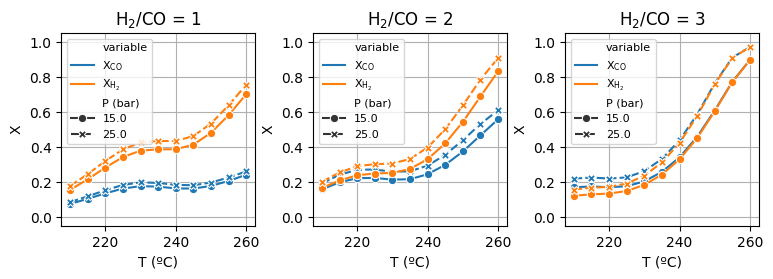

In [27]:
fig, axs = plt.subplots(1,3, figsize=(9,2.5))
plt.subplots_adjust(wspace=0.3)

sns.lineplot(
                data=plot_T_vs_X.loc[(plot_T_vs_X[r'$\mathrm{H_2/CO}$'] == 1) & (plot_T_vs_X['P (bar)'].isin([15,25]))], 
                x='T (ºC)', 
                y='value', 
                ax = axs[0],
                hue = 'variable',
                style = 'P (bar)',
                markers = True,
)

axs[0].set_ylim(-0.05,1.05)
axs[0].grid('both')
axs[0].set_ylabel('X')
axs[0].legend(fontsize = 8)
axs[0].set_title(r'$\mathrm{H_2/CO}$ = 1')

sns.lineplot(
                data=plot_T_vs_X.loc[(plot_T_vs_X[r'$\mathrm{H_2/CO}$'] == 2) & (plot_T_vs_X['P (bar)'].isin([15,25]))], 
                x='T (ºC)', 
                y='value', 
                ax = axs[1],
                hue = 'variable',
                style = 'P (bar)',
                markers = True,
)

axs[1].set_ylim(-0.05,1.05)
axs[1].grid('both')
axs[1].set_ylabel('X')
axs[1].legend(fontsize = 8)
axs[1].set_title(r'$\mathrm{H_2/CO}$ = 2')

sns.lineplot(
                data=plot_T_vs_X.loc[(plot_T_vs_X[r'$\mathrm{H_2/CO}$'] == 3) & (plot_T_vs_X['P (bar)'].isin([15,25]))], 
                x='T (ºC)', 
                y='value', 
                ax = axs[2],
                hue = 'variable',
                style = 'P (bar)',
                markers = True,
)

axs[2].set_ylim(-0.05,1.05)
axs[2].grid('both')
axs[2].set_ylabel('X')
axs[2].legend(fontsize = 8)
axs[2].set_title(r'$\mathrm{H_2/CO}$ = 3')

In [25]:
parametric_data.columns

Index(['P (bar)', 'T (ºC)', '$\mathrm{v_{CO,in}}$ (mL/min)',
       '$\mathrm{v_{H_2,in}}$ (mL/min)', '$\mathrm{X_{CO}}$',
       '$\mathrm{X_{H_2}}$', 'F_H2_out', 'F_CO_out', 'm_C1_C3', 'm_C9_C15',
       'm_C16p', 'm_water', 'C9_C15_sel', '$\mathrm{H_2/CO}$',
       '$\mathrm{\dot{m}_{C1-C3}}$ (g/d)', '$\mathrm{\dot{m}_{C9-C15}}$ (g/d)',
       '$\mathrm{\dot{m}_{C16+}}$ (g/d)', '$\mathrm{\dot{m}_{H_2O}}$ (g/d)'],
      dtype='str')

C:\Users\rafael\AppData\Local\Temp\ipykernel_6896\2298458557.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1))


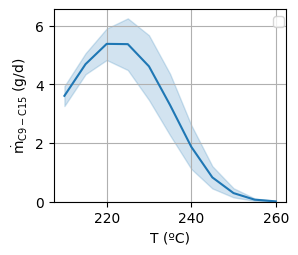

In [30]:
plot_C9_C15 = parametric_data[[r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)',
                               'T (ºC)', 
                               r'$\mathrm{H_2/CO}$', 
                               'P (bar)']].melt(id_vars = ['T (ºC)', 'P (bar)',
                                                           r'$\mathrm{H_2/CO}$'])

fig, axs = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=plot_C9_C15, 
                x='T (ºC)', 
                y='value', 
                ax = axs,
                markers = True,
)

plt.ylim(0,None)
plt.grid('both')
plt.ylabel(r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)')
plt.legend(bbox_to_anchor=(1.02, 1))

C:\Users\rafael\AppData\Local\Temp\ipykernel_6896\1306629369.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1))


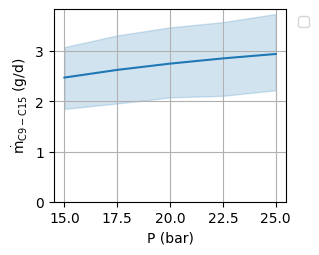

In [32]:
fig, axs = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=plot_C9_C15, 
                x='P (bar)', 
                y='value', 
                ax = axs,
                markers = True,
)

plt.ylim(0,None)
plt.grid('both')
plt.ylabel(r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)')
plt.legend(bbox_to_anchor=(1.02, 1))

C:\Users\rafael\AppData\Local\Temp\ipykernel_6896\149621788.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1))


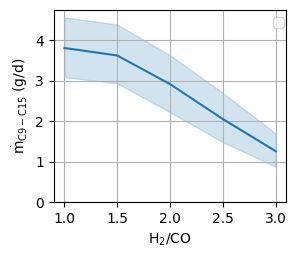

In [33]:
fig, axs = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=plot_C9_C15, 
                x=r'$\mathrm{H_2/CO}$', 
                y='value', 
                ax = axs,
                markers = True,
)

plt.ylim(0,None)
plt.grid('both')
plt.ylabel(r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)')
plt.legend(bbox_to_anchor=(1.02, 1))